# Batch vs Streaming Performance Comparison
# YouTube Comment Sentiment Analysis — HPDP Project 2

This notebook compares the performance of batch processing vs streaming mode
using the same SVM classifier and dataset. Metrics measured include total
processing time, throughput, classification accuracy, memory usage, and CPU usage.


# Cell 0: Train and Save SVM Model

Retrains the TF-IDF vectorizer and linear SVM classifier on the full
dataset if the model files are not already present. Splits data 80/20
for training and testing, then saves both model artifacts as .pkl files
to /content/models/ for use in the performance comparison cells below.



In [2]:
import pandas as pd, joblib, os
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

CSV_PATH  = '/content/youtube_comments_with_sentiment.csv'
MODEL_DIR = '/content/models'
os.makedirs(MODEL_DIR, exist_ok=True)

df = pd.read_csv(CSV_PATH)
df = df[['comment_clean', 'sentiment']].dropna()
label_map = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
df['label'] = df['sentiment'].map(label_map)

X_train, X_test, y_train, y_test = train_test_split(
    df['comment_clean'].values, df['label'].values,
    test_size=0.2, random_state=42, stratify=df['label']
)
tfidf = TfidfVectorizer(max_features=5000)
svm   = SVC(kernel='linear', probability=True)
svm.fit(tfidf.fit_transform(X_train), y_train)

joblib.dump(svm,   os.path.join(MODEL_DIR, 'svm_model.pkl'))
joblib.dump(tfidf, os.path.join(MODEL_DIR, 'tfidf_vectorizer.pkl'))
print('Models retrained and saved!')

Models retrained and saved!


# Cell 1: Load Data and Models
Loads the YouTube comments CSV and the saved SVM + TF-IDF model files.
Defines shared variables used across all comparison cells: feature # array
X, true label array y_true, label mappings, and total record count.

In [3]:
import pandas as pd
import numpy as np
import time
import psutil
import os
import matplotlib.pyplot as plt
import joblib
from sklearn.metrics import accuracy_score

CSV_PATH   = '/content/youtube_comments_with_sentiment.csv'
MODEL_DIR  = '/content/models'
OUTPUT_DIR = '/content/streaming_output'

df = pd.read_csv(CSV_PATH)
df = df[['comment_clean', 'sentiment']].dropna()
svm   = joblib.load(os.path.join(MODEL_DIR, 'svm_model.pkl'))
tfidf = joblib.load(os.path.join(MODEL_DIR, 'tfidf_vectorizer.pkl'))
label_map   = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
reverse_map = {'Negative': 0, 'Neutral': 1, 'Positive': 2}

X = df['comment_clean'].values
y_true = df['sentiment'].map(reverse_map).values
total_records = len(df)
print(f'Total records: {total_records}')

Total records: 4470


# Cell 2: Batch Mode Benchmark
Processes the entire dataset in a single vectorized operation — the
standard batch processing approach. Measures wall-clock time using
time.time(), CPU percentage using psutil.cpu_percent(), and memory
via process.memory_info(). Computes accuracy by comparing predictions
against true sentiment labels across all records.

In [4]:
print('\n--- Running BATCH MODE ---')

process = psutil.Process(os.getpid())
cpu_before_batch = psutil.cpu_percent(interval=1)
mem_before_batch = process.memory_info().rss / 1024 / 1024  # MB

batch_start = time.time()

X_vec      = tfidf.transform(X)
y_pred_raw = svm.predict(X_vec)
y_pred_batch = [label_map[int(p)] for p in y_pred_raw]

batch_end  = time.time()
batch_time = batch_end - batch_start

cpu_after_batch = psutil.cpu_percent(interval=1)
mem_after_batch = process.memory_info().rss / 1024 / 1024

batch_accuracy   = accuracy_score(y_true, y_pred_raw)
batch_throughput = total_records / batch_time

print(f'Batch processing time : {batch_time:.4f}s')
print(f'Batch throughput      : {batch_throughput:.2f} records/sec')
print(f'Batch accuracy        : {batch_accuracy:.4f}')
print(f'CPU usage             : {cpu_after_batch:.1f}%')
print(f'Memory usage          : {mem_after_batch:.1f} MB')


--- Running BATCH MODE ---
Batch processing time : 1.4519s
Batch throughput      : 3078.80 records/sec
Batch accuracy        : 0.9230
CPU usage             : 54.5%
Memory usage          : 266.0 MB


# Cell 3: Streaming Mode Benchmark
Simulates streaming by classifying one record at a time in a loop —
replicating how Spark Structured Streaming processes individual messages
from Kafka. Uses 500 records as the sample, then extrapolates total
time to the full dataset size for a fair comparison against batch mode.
Measures the same CPU, memory, accuracy, and throughput metrics.


In [5]:
print('\n--- Running STREAMING MODE ---')

STREAM_SAMPLE = 500
X_stream = X[:STREAM_SAMPLE]
y_stream = y_true[:STREAM_SAMPLE]

cpu_before_stream = psutil.cpu_percent(interval=1)
mem_before_stream = process.memory_info().rss / 1024 / 1024

stream_start = time.time()

y_pred_stream = []
for text in X_stream:
    vec  = tfidf.transform([str(text)])
    pred = svm.predict(vec)[0]
    y_pred_stream.append(int(pred))

stream_end  = time.time()
stream_time = stream_end - stream_start

cpu_after_stream = psutil.cpu_percent(interval=1)
mem_after_stream = process.memory_info().rss / 1024 / 1024

stream_accuracy   = accuracy_score(y_stream, y_pred_stream)
stream_throughput = STREAM_SAMPLE / stream_time
stream_time_full  = (stream_time / STREAM_SAMPLE) * total_records

print(f'Streaming time (500 records)     : {stream_time:.4f}s')
print(f'Streaming time (extrapolated all): {stream_time_full:.4f}s')
print(f'Streaming throughput             : {stream_throughput:.2f} records/sec')
print(f'Streaming accuracy               : {stream_accuracy:.4f}')
print(f'CPU usage                        : {cpu_after_stream:.1f}%')
print(f'Memory usage                     : {mem_after_stream:.1f} MB')


--- Running STREAMING MODE ---
Streaming time (500 records)     : 0.7403s
Streaming time (extrapolated all): 6.6187s
Streaming throughput             : 675.36 records/sec
Streaming accuracy               : 0.9080
CPU usage                        : 2.0%
Memory usage                     : 266.0 MB


# Cell 4: Print Comparison Table
Prints a formatted side-by-side comparison table of all 5 performance
metrics between batch and streaming mode. Covers the 4 rubric
requirements: processing time (a), throughput (b), accuracy (c),
and resource usage — CPU and memory (d).


In [6]:
print('\n' + '='*60)
print(f'{"Metric":<35} {"Batch":>10} {"Streaming":>12}')
print('='*60)
print(f'{"Total Processing Time (s)":<35} {batch_time:>10.4f} {stream_time_full:>12.4f}')
print(f'{"Throughput (records/sec)":<35} {batch_throughput:>10.2f} {stream_throughput:>12.2f}')
print(f'{"Classification Accuracy":<35} {batch_accuracy:>10.4f} {stream_accuracy:>12.4f}')
print(f'{"Memory Usage (MB)":<35} {mem_after_batch:>10.1f} {mem_after_stream:>12.1f}')
print(f'{"CPU Usage (%)":<35} {cpu_after_batch:>10.1f} {cpu_after_stream:>12.1f}')
print('='*60)


Metric                                   Batch    Streaming
Total Processing Time (s)               1.4519       6.6187
Throughput (records/sec)               3078.80       675.36
Classification Accuracy                 0.9230       0.9080
Memory Usage (MB)                        266.0        266.0
CPU Usage (%)                             54.5          2.0


# Cell 5: Generate Performance Comparison Charts
Produces a 2x3 grid of bar charts — one per metric — visually comparing
batch (blue) vs streaming (orange) side by side. The 6th subplot is
replaced with a text summary box showing the throughput speedup ratio
and confirming accuracy consistency across both modes. The final chart
is saved as performance_comparison.png and auto-downloaded.


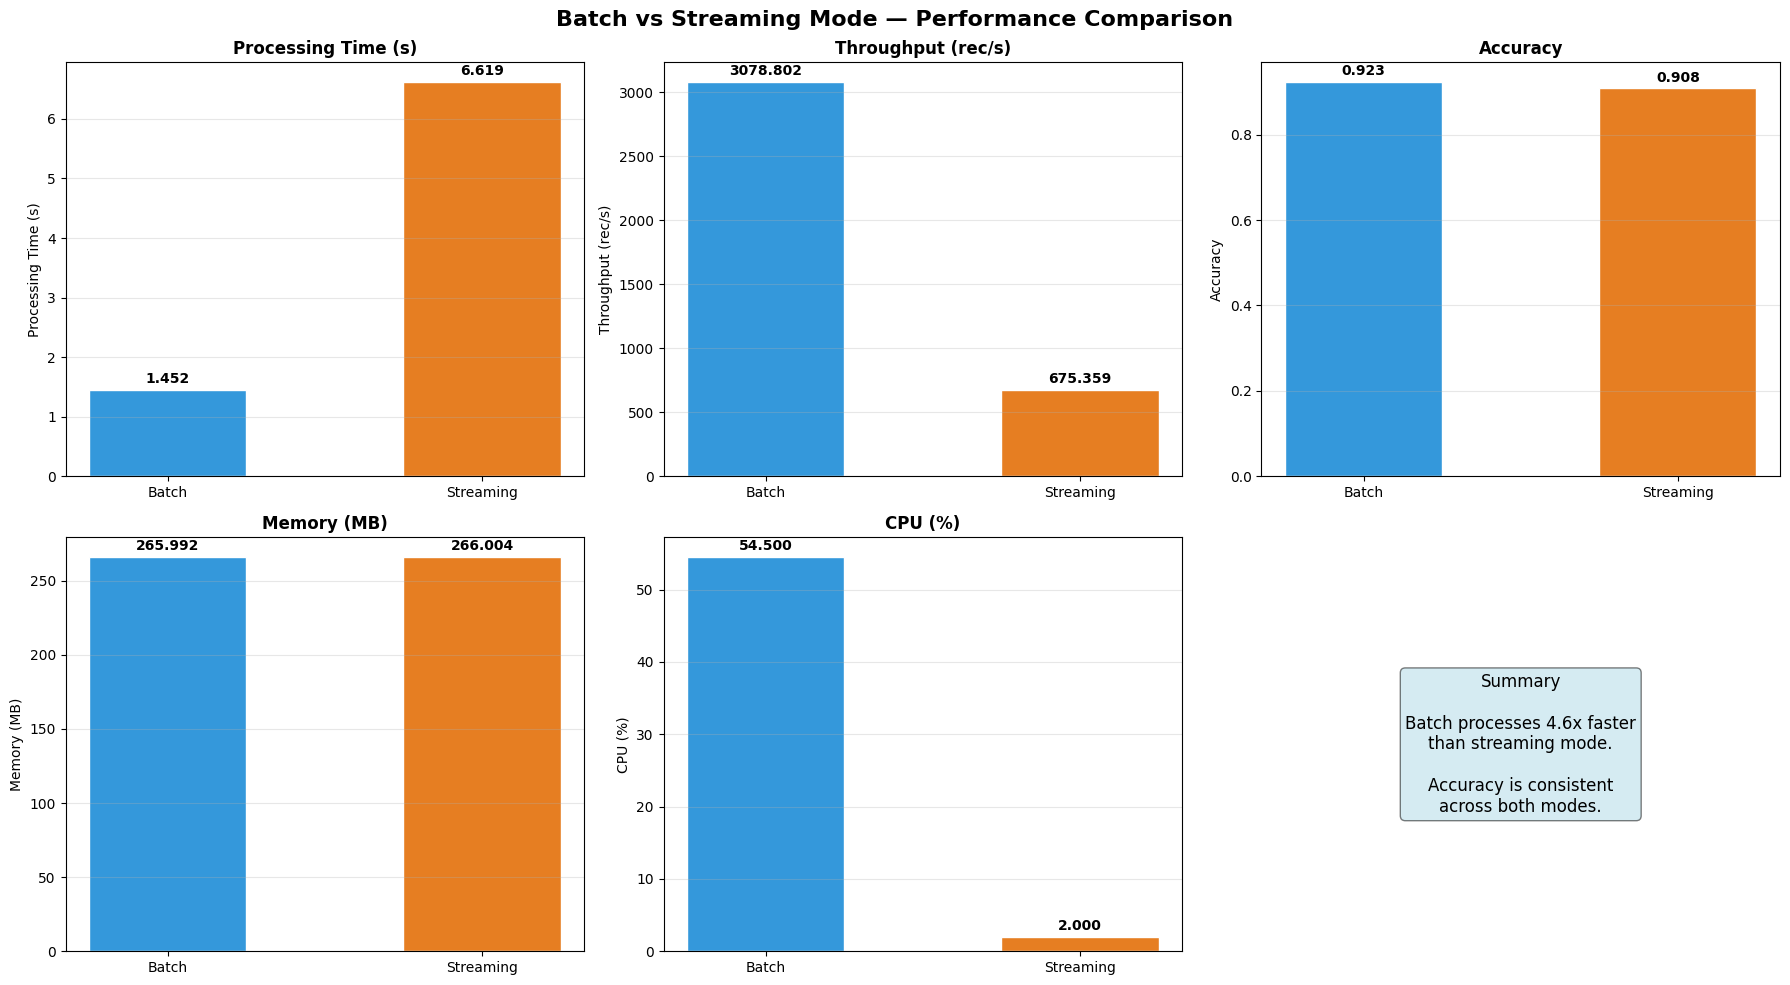

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Chart saved and downloaded!


In [7]:
metrics     = ['Processing Time (s)', 'Throughput (rec/s)', 'Accuracy', 'Memory (MB)', 'CPU (%)']
batch_vals  = [batch_time,      batch_throughput,  batch_accuracy,  mem_after_batch,  cpu_after_batch]
stream_vals = [stream_time_full, stream_throughput, stream_accuracy, mem_after_stream, cpu_after_stream]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Batch vs Streaming Mode — Performance Comparison', fontsize=16, fontweight='bold')
axes = axes.flatten()

colors_batch  = '#3498db'
colors_stream = '#e67e22'

for i, (metric, bv, sv) in enumerate(zip(metrics, batch_vals, stream_vals)):
    ax = axes[i]
    bars = ax.bar(['Batch', 'Streaming'], [bv, sv],
                  color=[colors_batch, colors_stream], edgecolor='white', width=0.5)
    ax.set_title(metric, fontweight='bold')
    ax.set_ylabel(metric)
    for bar, val in zip(bars, [bv, sv]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(bv, sv)*0.01,
                f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
    ax.grid(axis='y', alpha=0.3)

axes[5].axis('off')
axes[5].text(0.5, 0.5,
    f'Summary\n\nBatch processes {batch_throughput/stream_throughput:.1f}x faster\n'
    f'than streaming mode.\n\nAccuracy is consistent\nacross both modes.',
    ha='center', va='center', fontsize=12,
    bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.tight_layout()
plt.savefig('/content/performance_comparison.png', dpi=150)
plt.show()

from google.colab import files
files.download('/content/performance_comparison.png')
print('Chart saved and downloaded!')